## The script load raw images from epixquad1kfps data
### Yusong, Starting on 2025/12/29, Sunnyvale
#### The script is the basic LCLS-II DataSource based analysis on the epix.raw.calib
#### Load the raw IoC, threshold/raw averaging, running hitFinding analysis
#### Runnign the HitFinding analysis and invest the parameter spaces
#### Check the statistics after the HitFinding analysis
##### Ref: LCLS-II DAQ and DataSource: https://confluence.slac.stanford.edu/spaces/LCLSIIData/pages/267391733/psana#psana-Environment
##### Ref: LCLS-II UED related data analysis: https://docs.google.com/document/d/1u03HnIyQ5vY1g3JhSzi9mqnfw6FGB3QSnVwpfn8AMlc/edit?tab=t.0

In [29]:
import os,sys
import numpy as np
import configparser
import matplotlib.pyplot as plt
import matplotlib
import argparse
from psana import DataSource
from numba import jit, njit
import scipy.ndimage.measurements as smt
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *
from UEDePixTools import *
from tqdm import tqdm
from PIL import Image
from matplotlib.colors import LogNorm
# %matplotlib widget

In [30]:
# Check detector and scan variables
if 0 == 1:
    !detnames    exp='ued1015999',run=263 # non-epics detector names 
    !detnames -s exp='ued1015999',run=263 # scan variables
    if 0 == 1:
        !detnames -e exp='ued1015999',run=263 # epics detector names

In [31]:
# Check the Pedestal scan if needed: make sure the run is a pedestal run
if 1 == 0:
    ds = DataSource(exp='ued1015999',run=263) # Run 24 is one of the Pedestal scan for the commissioning experiment
    myrun = next(ds.runs())
    step_value = myrun.Detector('step_value')
    step_docstring = myrun.Detector('step_docstring')
    for step in myrun.steps():
        print(step_value(step),step_docstring(step))
        for evt in step.events():
            pass

In [32]:
# Setting an array looking into the single frames of the ePiX data
if 1 == 0:
    num_steps = np.shape(np.arange(52,56.25,0.25))[0]
    # shots_array = np.array()
    print(num_steps)
    arr = np.arange(1080 * 17)   # example: 5 blocks
    block_size = 1080
    pick = np.linspace(0, block_size - 1, 100, dtype=int)
    shots_array_pick = arr.reshape(-1, block_size)[:, pick]
    print(shots_array_pick)

In [33]:
# exp and run infor and load raw data using LCLS DataSource
exp = 'ued1015999'  # experiment
run = 115 # charge scan of Al on the 
# max_events = num_steps*1080 # how many shots to load
max_events = 540 # how many shots to load
ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
# ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
myrun  = next(ds.runs()) # Load runs
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps') # Detector
evt    = next(myrun.events()) # event
steps  = myrun.steps() 

In [20]:
# Loop the evt and load ePix data
img_shape    = [775,793] # Define the dimention of the image
calib_evts   = [] # Modules
# img_raw_evts = [] # Raw images
step_v_evt   = []
thrs_raw     = 40 # Set a threshold for the ePix raw frame
img_raw_evts_select = []
evt_count = 0 # counters for evt
for evt in myrun.events():
    if 0 == 1:
        if (evt_count%1080 >= 0) and (evt_count%1080 <=49):
            # print(evt_count)
            calib = epix.raw.calib(evt) # Load modules
            img_raw_evts_select.append(epix.raw.image(evt,calib))
            step_v_evt.append(step_v(evt))
    if 1 == 1:
        if (evt_count%540 == 0):
            print(evt_count)
        calib = epix.raw.calib(evt) # Load modules
        img_raw_evts_select.append(epix.raw.image(evt,calib))
        step_v_evt.append(step_v(evt))
    evt_count  = evt_count + 1
img_raw_evts_select = np.array(img_raw_evts_select) # Put it in to an array
step_v_evt = np.array(step_v_evt)
print('Finish loading the ePix IoC raw frames')

0
540
Finish loading the ePix IoC raw frames


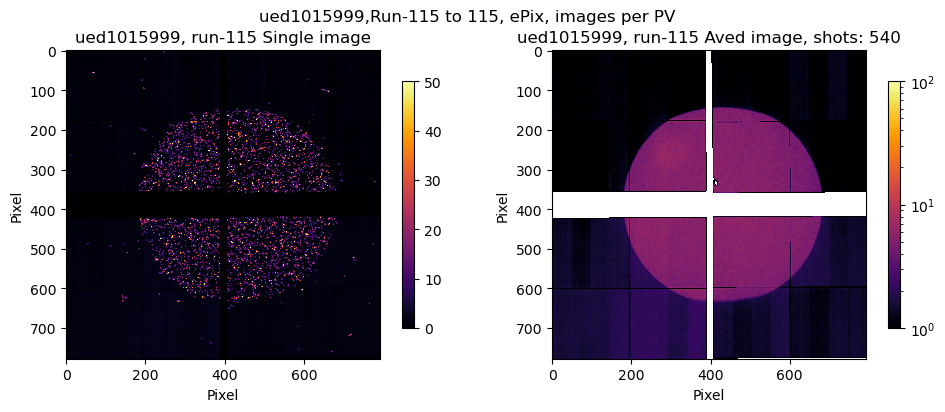

In [7]:
# Check the individual images and averaged images
img_sgl = img_raw_evts_select[5] # Check one image
plt.figure(figsize = (10,4))
plt.suptitle(exp+',Run-'+str(run)+' to '+str(run)+', ePix, images per PV')

plt.subplot(121)
plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=50);plt.colorbar(shrink=0.8)
plt.title(exp+', run-'+str(run)+' Single image');plt.xlabel('Pixel');plt.ylabel('Pixel');

plt.subplot(122)
img_raw_evts_ave = img_raw_evts_select[0:max_events].mean(axis=0);
# plt.imshow(img_raw_evts_ave, cmap='inferno');
plt.imshow(np.transpose(img_raw_evts_ave),norm=LogNorm(1,100), cmap='inferno');plt.colorbar(shrink=0.8)
plt.title(exp+', run-'+str(run)+' Aved image, shots: '+str(max_events));plt.xlabel('Pixel');plt.ylabel('Pixel');

plt.tight_layout()
plt.show()

# Save the data of the npy array
if 1 == 0:
    pathAnaSave = '/sdf/home/y/yusongl/UED/ana/Run5Analysis/ued1006392_1011071/data_save/';
    # Save the acetophenone signal
    pathAnaSave_name = pathAnaSave + exp +'_'+str(run)+'_raw_frames.npy'
    np.save(pathAnaSave_name, {'num_raw_evts':max_events,'img_raw_evts_select':img_raw_evts_select[0:max_events]})

In [8]:
# Define some trial peak finding parameters
max_electrons = 1000 # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal
# delete the dataSource to obtain the new DataSource
try:
    ds  # Try to access the variable
    print("ds exists!")
    print("ds deleted!")
    del ds
except NameError:
    print("ds does not exist.")

ds exists!
ds deleted!


In [17]:
# Running the peak finding 
beamCenter = np.array([397,309]) # set the center manually if needed
calib_evts     = [] # Modules of each evt
img_raw_evts   = [] # Raw images
x_evts         = [] # Peak X coordinates
y_evts         = [] # Peak Y coordinates
Intensity_evts = [] # Peak intenisties
Size_evts      = [] # Peak pixel size
n_peaks_evts   = [] # 
step_evts      = [] # Delay stage position
max_events     = 450 # Load a few frames
# Load the data from xtc files

exp = 'ued1015999'  # experiment
run = 491 # charge scan of Al on the 

ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load the xtc file using DataSource infrastructure
myrun  = next(ds.runs()) # Load runs
# step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps')
evt    = next(myrun.events())

evt_count = 0 # Counter of the event
for evt in myrun.events():# sometimes dectecor doesn't have 'epixquad' resulting in badness
    # try:
    #     epix = myrun.Detector('epixquad1kfps')
    # except AttributeError:
    #     continue
    calib = epix.raw.calib(evt)
    if calib is None: # this can return none, skip if it does
        continue
    evt_count = evt_count + 1;
    if evt_count%100 == 0:
        print('Looking at evt # '+str(evt_count))
    
    # read step value
    # step_value = step_v(evt)

    # define output arrays for peaks then populate them
    n_peaks = np.zeros(calib.shape[0])
    x = np.zeros((calib.shape[0], max_electrons))
    y = np.zeros((calib.shape[0], max_electrons))
    intensities = np.zeros((calib.shape[0], max_electrons))
    sizes = np.zeros((calib.shape[0], max_electrons))
    
    # The the peakFinding algrithem
    for i,module in enumerate(calib): # loop the number of quadrants
        n, _x, _y, _ints, _sizes = blobCounter(module, threshold, min_signal)
        n_peaks[i] = n
        # either fill in first max_electrons if n>max_electrons, or fill in first n
        if n > max_electrons:
            x[i] = _x[:max_electrons]
            y[i] = _y[:max_electrons]
            intensities[i] = _ints[:max_electrons]
            sizes[i] = _sizes[:max_electrons]
        else:
            x[i][:n] = _x
            y[i][:n] = _y
            intensities[i][:n] = _ints
            sizes[i][:n] = _sizes
    calib_evts.append(calib)
    x_evts.append(x);
    y_evts.append(y);
    Intensity_evts.append(intensities);
    Size_evts.append(sizes);
    step_evts.append(0); # if not existed
    # step_evts.append(step_value);
    n_peaks_evts.append(n_peaks)
x_evts = np.array(x_evts)
y_evts = np.array(y_evts)
Intensity_evts = np.array(Intensity_evts)
Size_evts = np.array(Size_evts)
n_peaks_evts = np.array(n_peaks_evts)
step_evts = np.array(step_evts)
print(str(evt_count)+' evts are loaded')
print('Finish peak finding')
print('Delays are:'+str(np.unique(step_evts)));

Looking at evt # 100
Looking at evt # 200
Looking at evt # 300
Looking at evt # 400
449 evts are loaded
Finish peak finding
Delays are:[0]


In [18]:
np.save('catalog/Intensity_evts'+str(run)+'.npy', Intensity_evts)

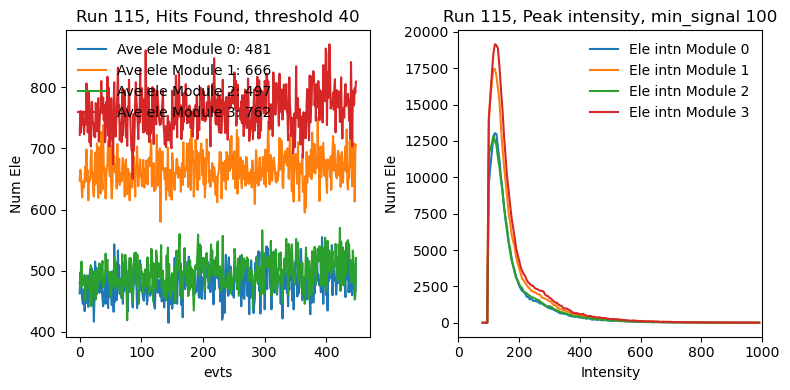

In [13]:
# Plot the results of trial peakFinding results
# Plot the number of peaks found at each quad
# plot number of electron found per shot
NumEle = np.count_nonzero(x_evts,axis=2)
fig, axes = plt.subplots(1,2,figsize=(8, 4))
# cmapLim = [0,100]
for i_mdl in range(4):
     axes[0].plot(NumEle[:,i_mdl],label=r"Ave ele Module %i: %i"%(i_mdl,np.mean(NumEle[:,i_mdl])))
axes[0].legend(framealpha=0)
axes[0].set_xlabel('evts');axes[0].set_ylabel('Num Ele');axes[0].set_title('Run '+str(run)+', Hits Found, threshold '+str(threshold));

bins_intn=np.arange(80,1000,5)
for i_mdl in range(4):
    hist_intn, bin_edges = np.histogram(Intensity_evts[:,i_mdl,:].flatten(), bins = bins_intn)
    axes[1].plot(bin_edges[0:-1],hist_intn,label=r"Ele intn Module %i"%(i_mdl))
axes[1].legend(framealpha=0)
axes[1].set_xlabel('Intensity');axes[1].set_ylabel('Num Ele');axes[1].set_title('Run '+str(run)+', Peak intensity, min_signal '+str(min_signal));
plt.xlim([0,1000])
plt.tight_layout()
plt.show()

In [14]:
# Put together the hitogram images
scale                    = 1 # - integer, the scale by which the output image will exceed the size of the detector (eg 3 breaks each pixel into 9) to take advantage of sub-pixel interpolation of peak centers.  1 returns images the same size as the detector, it is advised not to set much above 10.
filter_int_min           = 125 # - The minimum peak intensity to be included, typically 125.
filter_int_max           = 100000 # - The maximum peak intensity to be considered, useful for cosmic ray removal, direct beam removal, or to suppress peaks from multiple electron hits.
filter_size_min          = 1 #- The minimum peak size, in pixels, to be considered.  Typically 1.
filter_size_max          = 2000 # - The maximum peak size, in pixels, to be considered.  For limiting to single electron counting should be 4, to include double electron hits 8, or higher for many electrons.
count_multiple_electrons = 1 # - 0 or 1.  0 - all peaks are assigned as single electron.  1 - the peak intensity is used to calculate the most likely number of electrons contributing.  This is calculated as max(1, intensity//electron_signal).
apply_centroid_offset    = 0 # - 0 or 1.  0 - the centroid is not used.  1 - the output is corrected for beam jitter using the centroids in the h5file.  Requires reliable centroids from the h5file.
modules                  = (0,1,2,3)
step_evts = np.zeros_like(step_evts)
# Build up the filtered shots conditions
shot_filter = build_shot_filter(x_evts, y_evts, Intensity_evts, Size_evts,
                                min_intensity=filter_int_min, max_intensity=filter_int_max,
                                min_size=filter_size_min, max_size=filter_size_max)

# Get a dictionary of step:imagesArray
run_summary_imgs = make_run_image(x_evts, y_evts, Intensity_evts, shot_filter, step_evts,
                                modules=modules, scale=scale, 
                                allow_multiple_electrons=count_multiple_electrons)

combined_data = make_friendly_data(x_evts, y_evts, Intensity_evts, Size_evts, shot_filter, modules=modules) # combine the datafriendly type
posis = np.unique(step_evts) # return the stage positions
# posis = 

1295318


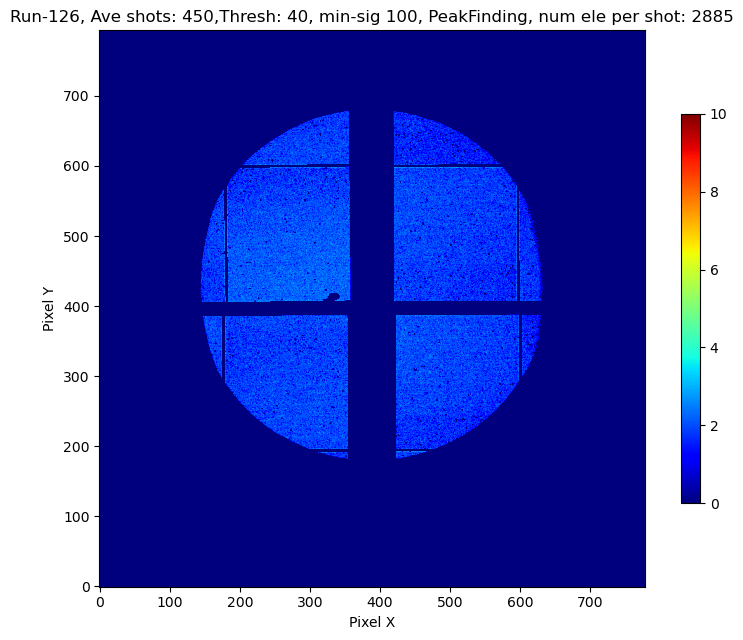

In [12]:
# Plot the averaged hit found images
img_hit_sgl = epix.raw.image(evt,run_summary_imgs[posis[0]]) # Put together the images
NumEle = np.count_nonzero(x_evts)
print(NumEle)
fig, ax = plt.subplots(figsize=(8,6.5))
cmapLim = [-0,10]
im = ax.imshow(np.log(img_hit_sgl+0.00001),cmap='jet',origin='lower',vmin = cmapLim[0], vmax = cmapLim[1])
fig.colorbar(im,ax=ax, orientation='vertical', shrink=0.7)
ax.set_xlabel('Pixel X');ax.set_ylabel('Pixel Y');ax.set_title('Run-'+str(run)+', Ave shots: '+str(max_events)+',Thresh: '+str(threshold)+', min-sig '+str(min_signal)+', PeakFinding, num ele per shot: '+str(round(NumEle/evt_count)));
# ax.set_xlim([200,600])
# ax.set_ylim([150,550])
# plt.xlim([200,600])
# plt.ylim([100,500])
plt.tight_layout()
plt.show()

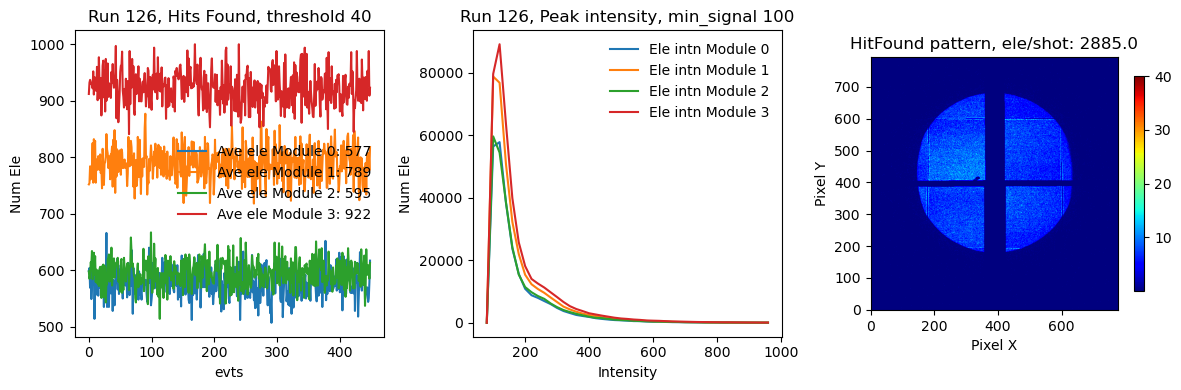

In [13]:
NumEle = np.count_nonzero(x_evts,axis=2)
fig, axes = plt.subplots(1,3,figsize=(12, 4))
# cmapLim = [0,100]
for i_mdl in range(4):
     axes[0].plot(NumEle[:,i_mdl],label=r"Ave ele Module %i: %i"%(i_mdl,np.mean(NumEle[:,i_mdl])))
axes[0].legend(framealpha=0)
axes[0].set_xlabel('evts');axes[0].set_ylabel('Num Ele');axes[0].set_title('Run '+str(run)+', Hits Found, threshold '+str(threshold));

bins_intn=np.arange(80,1000,20)
for i_mdl in range(4):
    hist_intn, bin_edges = np.histogram(Intensity_evts[:,i_mdl,:].flatten(), bins = bins_intn)
    axes[1].plot(bin_edges[0:-1],hist_intn,label=r"Ele intn Module %i"%(i_mdl))
axes[1].legend(framealpha=0)
axes[1].set_xlabel('Intensity');axes[1].set_ylabel('Num Ele');axes[1].set_title('Run '+str(run)+', Peak intensity, min_signal '+str(min_signal));

NumEle = np.count_nonzero(x_evts)
cmapLim = [0,40]
im = axes[2].imshow((img_hit_sgl+0.00001),cmap='jet',origin='lower',vmax = cmapLim[1])
fig.colorbar(im,ax=axes[2], orientation='vertical', shrink=0.7)
axes[2].set_xlabel('Pixel X');axes[2].set_ylabel('Pixel Y');axes[2].set_title('HitFound pattern, ele/shot: '+str(np.round(NumEle/evt_count)));

plt.tight_layout()
plt.show()